# General notebook

In [32]:
using Revise
Revise.retry() # Just in case if only Revise is not sufficient. 
include("lattice_protein.jl")

Imports done, importing hamiltonian path
hamiltonian path imported, importing metropolis
metropolis imported, importing benchmark
benchmark imported, importing visualization
visualization imported, importing tree
tree imported, importing lattice_protein


## Hamiltonian paths

In [2]:
println("We find $(length(PATHS)) unique paths.")
println(first(PATHS))

We find 103346 unique paths.
Int8[1, 2, 3, 6, 5, 4, 7, 8, 9, 18, 17, 16, 13, 14, 15, 12, 11, 10, 19, 20, 21, 24, 23, 22, 25, 26, 27]


Contact map for the first path:
Path visualization for the 75005:


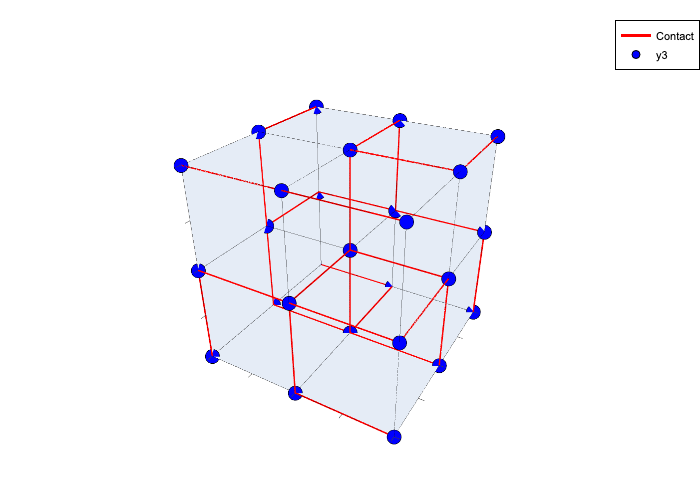

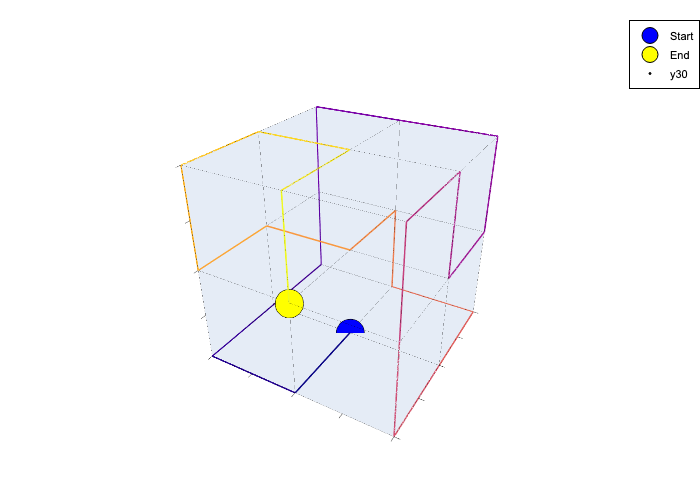

In [3]:
println("Contact map for the first path:")
liste_contact = contact_map(PATHS[75005])
display(plot_cube_ctc_map(x, y, z, lx, ly, lz, liste_contact))

println("Path visualization for the 75005:")
display(plot_cube_path(x, y, z, lx, ly, lz, PATHS[75005]))

## Metropolis general results

Attention : si on veut changer de matrice (MJ*5 ou MJ_1996) il faut restart le kernel et modifier la ligne const dans le ficher metropolis.jl. 

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:01:09


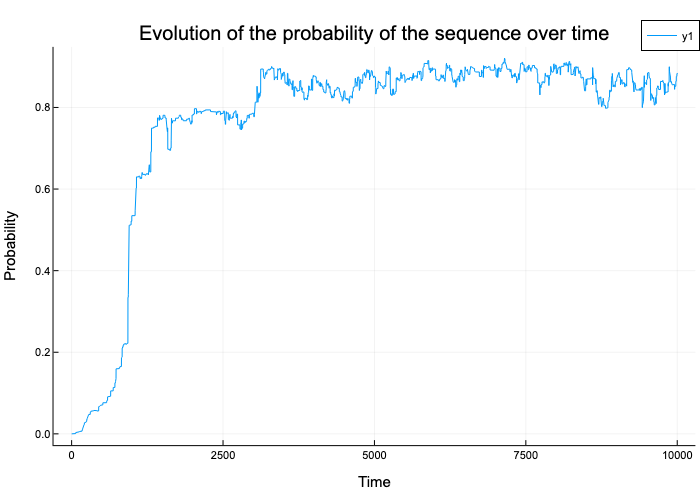

In [4]:
# with all the data
seq = generate_seq()
print(matrix_name)
target_number = 75005
all_ctc_maps = all_contact_maps(PATHS)
plot_probability(seq, target_number, all_ctc_maps, 10000)

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


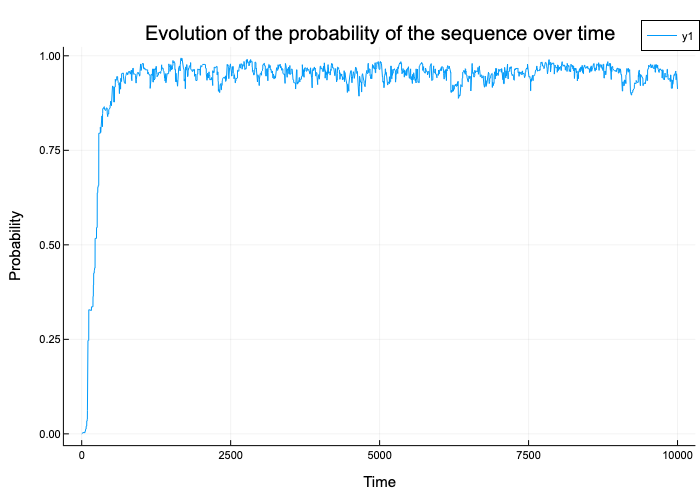

In [5]:
# with few data
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
print(matrix_name)

all_ctc_maps = all_contact_maps(paths_reduced)
plot_probability(seq, target_number, all_ctc_maps, 10000)

Testing beta = 10


algo (β=10) 100%|████████████████████████████████████████| Time: 0:00:02


Testing beta = 50


algo (β=50) 100%|████████████████████████████████████████| Time: 0:00:02


Testing beta = 100


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:02


Testing beta = 1000


algo (β=1000) 100%|██████████████████████████████████████| Time: 0:00:02


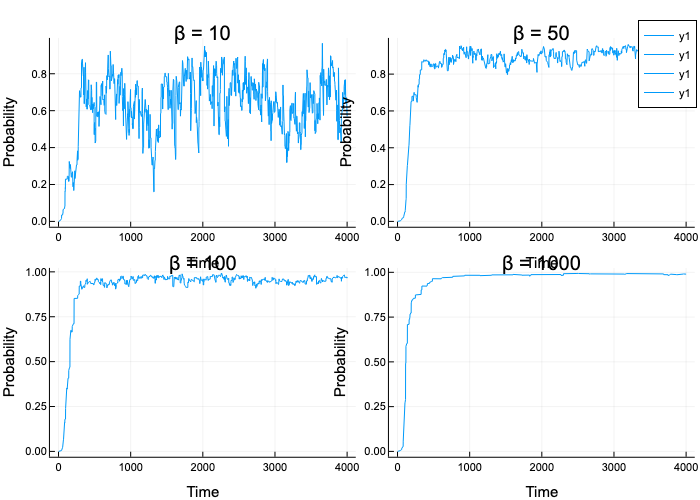

Dict{Float64, Tuple{Vector{Int64}, Vector{Float64}}} with 4 entries:
  50.0   => ([15, 20, 10, 19, 2, 14, 15, 10, 2, 18  …  2, 16, 16, 19, 6, 17, 8,…
  10.0   => ([8, 19, 17, 15, 16, 17, 19, 19, 6, 19  …  6, 16, 15, 13, 2, 12, 12…
  1000.0 => ([8, 5, 12, 16, 2, 17, 18, 1, 5, 1  …  1, 10, 18, 15, 3, 15, 15, 3,…
  100.0  => ([12, 11, 1, 18, 9, 18, 15, 7, 1, 1  …  4, 1, 19, 15, 16, 6, 16, 18…

In [6]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)


benchmark_beta()

## Further observations

### Chain evolution

ici

Multi-init 100%|█████████████████████████████████████████| Time: 0:00:22


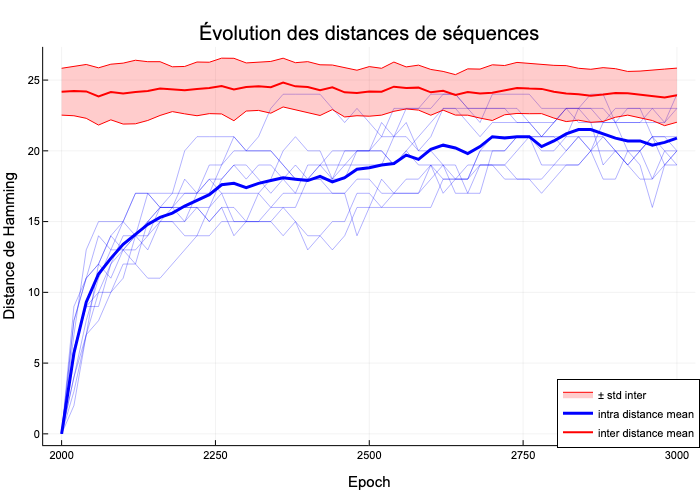

In [7]:
paths_reduced = reduce_data(PATHS, 10)
beta = 100.0

seq_over_time = multi_init_seq_over_time(target_number, all_ctc_maps, epochs=3000, beta=beta, threshold=2000, step=20, runs=10)
plot_distances_inter_intra(seq_over_time, beta=beta)

### All proba

In [8]:
final_seq, p_struct_time_t, p_final,_=algo_show_probability_distribution(seq, target_number, all_ctc_maps, 10000, 100)
show_sorted_indices(p_final)

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


structure 1234 : 0.9046258062136961
structure 1797 : 0.016568799596039987
structure 5133 : 0.00909315001441679
structure 10007 : 0.004295299925866987
structure 10031 : 0.0033451829457917417
structure 1736 : 0.0033451829457917357
structure 5137 : 0.0024781724777562892
structure 4417 : 0.0024781724777562675
structure 1816 : 0.0021329828185618687
structure 1207 : 0.0019300026662625734
structure 6454 : 0.0018358753255137978
structure 3084 : 0.001661168689373849
structure 3083 : 0.0016611686893738366
structure 10009 : 0.0016611686893738238
structure 10044 : 0.0015801525363916746
structure 1558 : 0.001503087587815211
structure 6432 : 0.001503087587815198
structure 10008 : 0.001230624032714112
structure 5048 : 0.0011706057904153895
structure 8386 : 0.0011706057904153854


### Mutations on the cube

In [28]:
# Mutations en fonction de la position
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234

all_ctc_maps = all_contact_maps(paths_reduced)

beta = 100

_, _, saved_seq = algo(seq, target_number, all_ctc_maps, 10000, beta, 2000, 200)
println("On a sauvegardé $(length(saved_seq)) structures.")

n_mutations_per_position = amount_of_mutations(saved_seq)
n_mutations_per_position


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:07


On a sauvegardé 41 structures.


Dict{Int64, Int64} with 27 entries:
  5  => 21
  16 => 26
  20 => 13
  12 => 29
  24 => 28
  8  => 30
  17 => 26
  1  => 39
  19 => 32
  22 => 16
  23 => 17
  6  => 31
  11 => 29
  9  => 13
  14 => 32
  3  => 35
  7  => 15
  25 => 14
  4  => 10
  ⋮  => ⋮

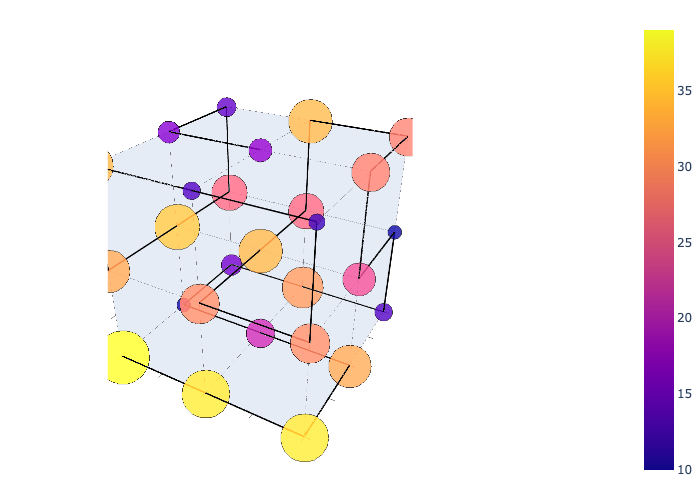

In [29]:
plot_cube_with_mutations_on_sphere(x, y, z, lx, ly, lz, PATHS[target_number], n_mutations_per_position)

In [33]:
beta = 100
target_number = 1234
epoch_start, epoch_stop, step = 2000, 10000, 200

paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
all_ctc_maps = all_contact_maps(paths_reduced)

_, _, saved_seq = algo(seq, target_number, all_ctc_maps, epoch_stop, beta, epoch_start, step)
println("On a sauvegardé $(length(saved_seq)) structures.")

plot_gif_cube_with_mutations(x, y, z, lx, ly, lz, PATHS[target_number], saved_seq)


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:07


On a sauvegardé 41 structures.
GIF sauvegardé : ../figures/mutations.gif


┌ Info: Saved animation to /Users/marie.gabilly/Documents/master/m1/s2/projet/figures/mutations.gif
└ @ Plots /Users/marie.gabilly/.julia/packages/Plots/AE0LB/src/animation.jl:156


## Tree generation

In [12]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
beta = 100

root_seq,p_struct_time_t,_ = algo(seq, target_number, all_ctc_maps, 5000, beta, 10000, 200, true)
proba_final_root = p_struct_time_t[end]
println(proba_final_root)

newick, seq_dict = create_genealogy(root_seq, 50, 2, target_number, all_ctc_maps, beta=100 )

println(newick)

# Charger l'arbre dans TreeTools
tree = parse_newick_string(newick)

for node in nodes(tree)
    name = label(node)
    println("$name : " * join([aa_idx[acid] for acid in seq_dict[name]], " "))
end

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


0.9837181760307013
((N3:50,N4:50)N2:50,(N6:50,N7:50)N5:50)N1;
N3 : PHE ASN LYS LYS LYS VAL ASP GLY HIS ASN ILE GLN VAL LEU VAL MET LYS ASP ASP ASP ARG LEU ASP PHE ILE SER VAL
N4 : ILE ASN LEU ARG LYS LEU ASP ILE ASN LYS CYS CYS LEU CYS VAL PHE GLY ASP ASP GLN ARG PHE THR LEU PHE LYS LEU
N5 : ILE ILE CYS LYS LYS SER GLU ASP LYS ARG LEU THR LYS PHE PHE ILE ASN ASP GLU ASP LYS VAL ASN MET LEU THR VAL
N7 : ASN GLN LYS LYS LYS VAL ASP VAL LYS LYS PRO THR ILE CYS VAL CYS ARG ASP GLU GLU LYS VAL SER VAL LEU GLY PHE
N1 : CYS GLU TRP LYS LYS TYR ASP ASP THR ASP VAL PHE MET CYS PHE PHE LYS ASP GLU ASP LYS LEU ASN LEU LEU ASN VAL
N6 : GLY GLU VAL LYS GLY MET GLU PHE LYS ARG VAL ALA MET LEU VAL ILE HIS ASP GLU ASP LYS VAL ARG LEU LEU GLU TYR
N2 : GLY ASN PHE ARG LYS ALA ASP GLY GLN LYS VAL ALA PHE VAL VAL PHE ASN ASP ASP ASP ARG PHE ASN LEU MET ARG ILE


In [13]:
simple_print_distance_matrix(seq_dict)

      N3    N4    N5    N7    N1    N6    N2    
N3    0     20    22    20    19    22    18    
N4    20    0     24    21    21    24    15    
N5    22    24    0     18    16    16    22    
N7    20    21    18    0     19    19    22    
N1    19    21    16    19    0     17    19    
N6    22    24    16    19    17    0     20    
N2    18    15    22    22    19    20    0     


In [14]:
p = plot_distance_matrix(seq_dict)
savefig(p, "../figures/distance_matrix.svg")

"/Users/marie.gabilly/Documents/master/m1/s2/projet/figures/distance_matrix.svg"

In [15]:
tree


                                        _____________________________________ N3
  _____________________________________|
 |                                     |_____________________________________ N4
_|
 |                                      _____________________________________ N6
 |_____________________________________|
                                       |_____________________________________ N7


In [16]:
result = fitch_reconstruction(tree, seq_dict)

for (name, seq) in sort(collect(result))
    println("$name : " * join([aa_idx[acid] for acid in seq], " "))
end

N1 : ILE GLN LYS LYS LYS VAL ASP ILE ASN LYS ILE GLN LEU LEU VAL ILE GLY ASP ASP ASP ARG LEU ASP LEU LEU GLU LEU
N2 : ILE ASN LYS LYS LYS VAL ASP ILE ASN LYS ILE GLN LEU LEU VAL MET GLY ASP ASP ASP ARG LEU ASP LEU ILE SER LEU
N3 : PHE ASN LYS LYS LYS VAL ASP GLY HIS ASN ILE GLN VAL LEU VAL MET LYS ASP ASP ASP ARG LEU ASP PHE ILE SER VAL
N4 : ILE ASN LEU ARG LYS LEU ASP ILE ASN LYS CYS CYS LEU CYS VAL PHE GLY ASP ASP GLN ARG PHE THR LEU PHE LYS LEU
N5 : GLY GLN LYS LYS LYS VAL ASP VAL LYS LYS VAL THR ILE LEU VAL ILE ARG ASP GLU ASP LYS VAL ARG LEU LEU GLU TYR
N6 : GLY GLU VAL LYS GLY MET GLU PHE LYS ARG VAL ALA MET LEU VAL ILE HIS ASP GLU ASP LYS VAL ARG LEU LEU GLU TYR
N7 : ASN GLN LYS LYS LYS VAL ASP VAL LYS LYS PRO THR ILE CYS VAL CYS ARG ASP GLU GLU LYS VAL SER VAL LEU GLY PHE


In [17]:
root_name_reconstructed, root_seq_reconstructed = first(sort(collect(result)))

"N1" => [4, 13, 19, 19, 19, 6, 16, 4, 14, 19  …  16, 16, 16, 18, 5, 16, 5, 5, 15, 5]

In [18]:
reconstruction_error_hamming(result, seq_dict)

7.428571428571429

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


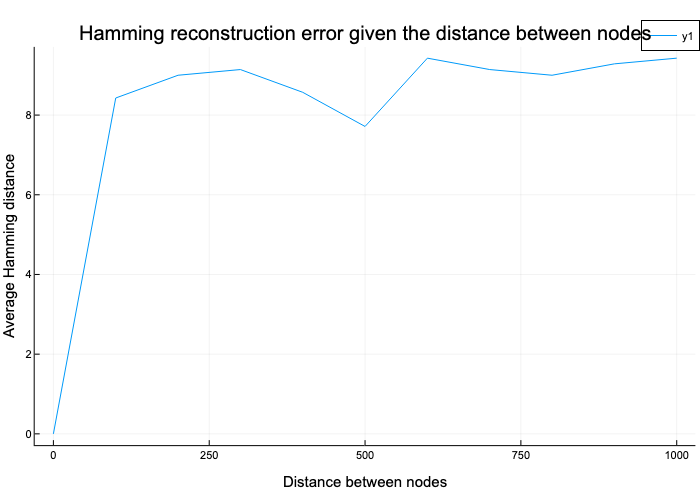

In [19]:
distance_btw_nodes = 0:100:1000
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
number_of_nodes = 2

root_seq,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)

plot_reconstruction_error_hamming(root_seq, distance_btw_nodes, number_of_nodes, target_number, all_ctc_maps, beta=100)

In [20]:
reconstruction_error_prob_folding(result, seq_dict, all_ctc_maps, target_number)

0.00948399227021465

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


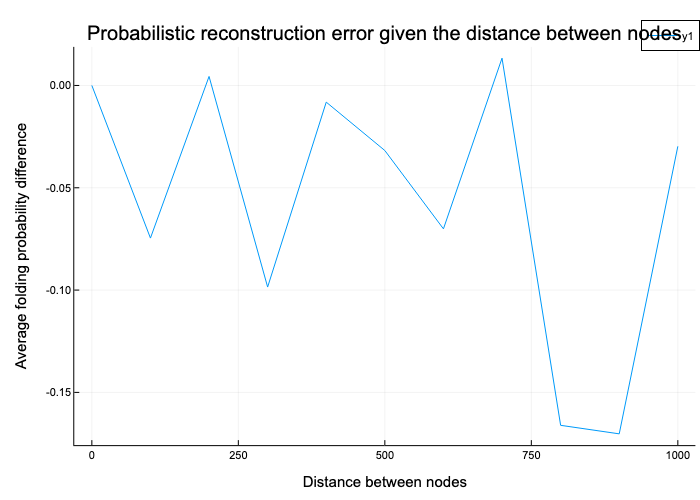

In [21]:
distance_btw_nodes = 0:100:1000
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
number_of_nodes = 2

root_seq,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)

plot_reconstruction_error_proba(root_seq, distance_btw_nodes, number_of_nodes, target_number, all_ctc_maps, beta=100)